In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_2d import Tile2Symb2dBin
from rendering.image import render_symbols_img

from tests.experimental.test_loop import lazy_converter_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
GENS = 20
GENS_STEP = 5
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

line_converter = HarmonyLineSearch(symbols=SYMBOLS,
                                   font=FONT,
                                   generations=GENS,
                                   tile_converter=Tile2Symb2dBin(symbols=SYMBOLS, font=FONT))

converter = ImgConverter(line_converter, FONT)

line_height = int(FONT_SIZE * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=1000)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| """Fv*oD&&"Yw*dw==~  |  MSZQN#=^$wQWWN${$W/ | XP0UY. ^:uesAxsH%T'  |
| qqqqqqqqqquuqu;;;;,_ | .`*]$w06^F!@0&^TC`]` | MdLy(=Dn,e^c_::_,  . |
| !Q]B@W#WUmgQWQQhN_yt | uoeZ$$Z?"' `7[eeedZt | 1z*TCZBu#W%mNyugQ%Me |
| $%MWM;a_`pQQQQ$'$$S. | I\ne$$@|. ` iAmQ9R67 | Y/]zc""k7OQ}=h^l:!P^ |
| J__<QQE3@g@gpv B^:f` | :6Ptm$$b'   ]Z1d%qZL | @MsDq !+/?w```!~!:_, |
| ;$@g@@@%$@@WWNNt_+z" | HLQGMO$$( .q.'"Y=yU3 | ><;*  +-:_ ,;uepOB06 |
| ^,^^^^^`^^^^.^^^^"'' | '^''`'^^``''` ` '''' |  ` `  ''''''''''''^' |
----------------------------------------------------------------------
-----------------------------------------------------------------
|   ``` ``````  ` | rwM&m%Mm  ~wZ$m;2_U$ | ZZyuc+cS9E6deZZeZesL |
| `````.:``-````  | Q@QW%R##W$$ORR###MWW | N#RRResJ/\]jZY7(*?Y7 |
| pMmMWB0NPXVa+e- | *MQ@@4gwqw5[`'?/'^"B | wqqyc]l}5YkAbe))uua( |
| 8<mm@WMWWAwg6mj | #RRW@W%%P`'>?'       | Q$%MM#6[' :Z]agDA0l. |
| F'OMM(Z^. %D{UW | 4HkH?P%#,uP

Min: 0.0548 | Max: 0.1812 | Mean: 0.1217 | Std: 0.0337
Min: 0.0583 | Max: 0.1864 | Mean: 0.1360 | Std: 0.0409
Min: 0.0749 | Max: 0.2219 | Mean: 0.1496 | Std: 0.0404
Min: 0.0715 | Max: 0.2510 | Mean: 0.1588 | Std: 0.0497


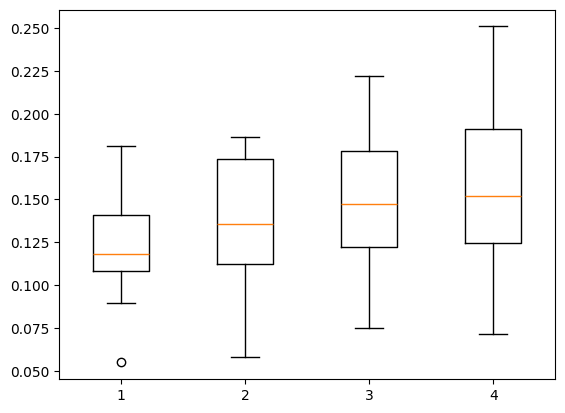

In [3]:
similarity_scores = lazy_converter_loop(IMG_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0478 | Max: 0.1195 | Mean: 0.0894 | Std: 0.0198
Min: 0.0488 | Max: 0.1344 | Mean: 0.0992 | Std: 0.0252
Min: 0.0466 | Max: 0.1577 | Mean: 0.1051 | Std: 0.0336
Min: 0.0426 | Max: 0.1705 | Mean: 0.1087 | Std: 0.0373


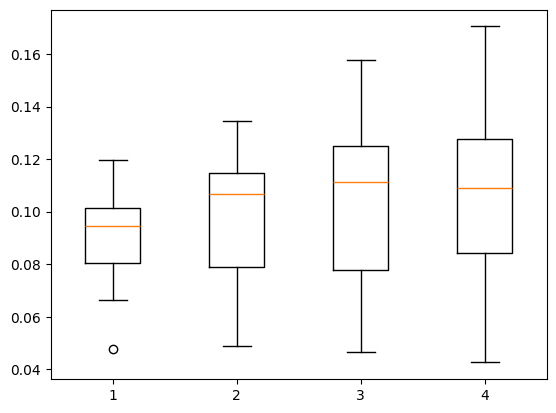

In [4]:
IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
                 for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_BIN_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0320 | Max: 0.3696 | Mean: 0.1624 | Std: 0.1047
Min: 0.0370 | Max: 0.4598 | Mean: 0.1820 | Std: 0.1239
Min: 0.0356 | Max: 0.4788 | Mean: 0.1933 | Std: 0.1287
Min: 0.0371 | Max: 0.5221 | Mean: 0.1970 | Std: 0.1365


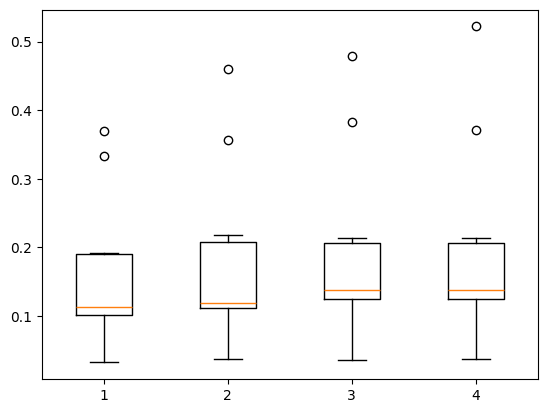

In [5]:
IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
                  for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_EDGE_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        